# **Music Genre Classification Project**

Final project for the course *Selected Topics in Music and Acoustic Engineering*, task number 5: **Music Genre Classification**.

**Group Members**:
- Eleonora Berra
- Federico Giacopuzzi
- Tekla Gizella Kalmár
- Antonio Treviglio

*Part of the code is commented in order to make execution time lighter.*

## **0. Imported Libraries**

In [1]:
import numpy as np
import pandas as pd
import os
import random
import seaborn as sns
import pickle
import glob
import tqdm
import json
import librosa, librosa.display
import IPython.display as ipd

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import joblib
from joblib import Parallel, delayed

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, scale
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.utils import class_weight

from pathlib import Path

import tensorflow as tf
from keras import regularizers
from keras.models import Sequential, load_model
from keras.layers import (GlobalAveragePooling2D, AveragePooling2D, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Dense, Input, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, TimeDistributed, GlobalAveragePooling1D, LSTM)
from keras.optimizers import SGD, Adam
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.regularizers import l2

## **1. Import audio data**

In [2]:
# Define project root directories
DURATION = 30      # Seconds to load
TARGET_SR = 22050  # Standard for most MIR tasks
SAVE_DIR = './features_data' 
os.makedirs(SAVE_DIR, exist_ok=True)
AUDIO_DIR = os.path.abspath('./fma_small')
# Assuming the tracks.csv file is located in the root directory or a dedicated metadata folder
META_DIR = './fma_metadata' 
TRACKS_FILE = os.path.join(META_DIR, 'tracks.csv')

# Load the tracks.csv file
# FMA uses the first 3 rows as header (MultiIndex) and the first column as index (track_id)
try:
    print("Loading metadata...")
    tracks = pd.read_csv(TRACKS_FILE, index_col=0, header=[0, 1])
    
    # Filter the dataset: select only the 'small' subset
    small_tracks = tracks[tracks[('set', 'subset')] == 'small']
    
    print(f"Loading complete. Total number of tracks in the 'small' subset: {small_tracks.shape[0]}")
    
except FileNotFoundError:
    print(f"Error: File {TRACKS_FILE} not found. Please verify the directory paths.")

Loading metadata...
Loading complete. Total number of tracks in the 'small' subset: 8000


## **2. Import associated annotations**

In [3]:
# Get all audio files from directory
# Assuming tracks are in subdirectories like /fma_small/000/000002.mp3
audio_files = [str(p) for p in Path(AUDIO_DIR).rglob("*.mp3")]

# Create DataFrame from files
audio_df = pd.DataFrame({
    'path': audio_files,
    'track_id': [int(os.path.splitext(os.path.basename(p))[0]) for p in audio_files]
}).set_index('track_id')

# Join metadata (Inner join ensures only files present in metadata are kept)
genre_df = small_tracks[[('track', 'genre_top')]].copy()
genre_df.columns = ['genre']  # flatten MultiIndex column to avoid merge level mismatch
df = audio_df.join(genre_df, how='inner')

# Final cleanup
df = df.rename(columns={('track', 'genre_top'): 'genre'})
df = df.dropna(subset=['genre']).reset_index()

print(f"Dataset ready. Samples: {len(df)}")

Dataset ready. Samples: 8000


## **3. Normalize the data as needed**

In [ ]:
# def load_and_normalize(file_path, target_sr=TARGET_SR, duration=DURATION):
#     try:
#         # Load the audio file with librosa
#         y, sr = librosa.load(file_path, sr=target_sr, mono=True, duration=duration)
        
#         target_length = target_sr * duration
#         if len(y) < target_length:
#             y = np.pad(y, (0, target_length - len(y)), 'constant')
#         else:
#             y = y[:target_length]
            
#         rms = np.sqrt(np.mean(y**2))
#         if rms > 0:
#             y = y / (rms + 1e-6)
            
#         return y
#     except Exception as e:
#         # Logs the error and returns None
#         print(f"File corrotto o illeggibile: {file_path}")
#         return None

# def get_full_path(track_id):
#     tid_str = '{:06d}'.format(track_id)
#     return os.path.join(AUDIO_DIR, tid_str[:3], tid_str + '.mp3')

# df['path'] = df['track_id'].apply(get_full_path)

# n_cores = os.cpu_count() - 1
# audio_data_list = Parallel(n_jobs=n_cores)(
#     delayed(load_and_normalize)(path) for path in df['path']
# )

# # Assign to dataframe
# df['audio_data'] = audio_data_list
# df = df.dropna(subset=['audio_data'])

In [5]:
# Save the DataFrame to a pickle file
# 'pickle' preserves the NumPy array structure inside the 'audio_data' column
# df.to_pickle('processed_audio_df.pkl')
# print("DataFrame saved successfully.")

In [6]:
# How to load it in your next session
# This replaces the need to run the Parallel loading cell again
df = pd.read_pickle('processed_audio_df.pkl')
print("DataFrame loaded successfully.")

DataFrame loaded successfully.


## **4. Split the data into training, validation (optional), and test sets**

In [7]:
# Split into Training (80%) and Temporary (20%) sets
# 'stratify=df['genre']' ensures the genre distribution remains consistent 
# across all subsets, which is crucial for balanced model evaluation.
train_df, temp_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['genre']
)

# Split the Temporary set into Validation (10% of total) and Test (10% of total)
# Since temp_df is 20% of the data, a 0.5 test_size splits it exactly in half.
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['genre']
)

# Output summary to verify data distribution
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 6397
Validation size: 800
Test size: 800


## **5. Extract appropriate audio features**

| Feature | Role |
| :--- | :--- |
| **MFCCs** | Timbre (the "DNA" of the sound) |
| **Spectral Centroid** | Timbre (Brightness) |
| **Zero Crossing Rate** | Timbre (Noisiness/Percussiveness) |
| **Chroma Features** | Harmony (Key/Chords) |
| **Tempogram** | Rhythm (Tempo evolution) |

In [8]:
# # Extraction function definition
# def extract_features_lean(y, sr=TARGET_SR):
#     # CNN Input (2D representation)
#     mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
#     mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
#     # Lean 1D Feature Suite (Timbre, Harmony, Rhythm)
#     mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
#     spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
#     zcr = librosa.feature.zero_crossing_rate(y)
#     chroma = librosa.feature.chroma_stft(y=y, sr=sr)
#     oenv = librosa.onset.onset_strength(y=y, sr=sr)
#     tempogram = librosa.feature.tempogram(onset_envelope=oenv, sr=sr)
    
#     # Aggregation of statistical moments
#     # Consolidate mean and std for each feature into a single 1D vector
#     feature_list = [mfcc, spec_cent, zcr, chroma, tempogram]
#     features_1d = np.hstack([
#         np.hstack([np.mean(f, axis=1), np.std(f, axis=1)]) for f in feature_list
#     ])
    
#     return {'cnn_input': mel_spec_db, 'ml_input': features_1d}

# # Parallelization logic using all available CPU cores
# def get_features_parallel(df):
#     n_cores = os.cpu_count() - 1
#     # Distribute the extraction across CPU cores
#     results = Parallel(n_jobs=n_cores)(
#         delayed(extract_features_lean)(y) for y in df['audio_data']
#     )
    
#     # Reconstruct the feature arrays from parallel results
#     features_cnn = np.array([r['cnn_input'] for r in results])
#     features_ml = np.array([r['ml_input'] for r in results])
    
#     return features_cnn, features_ml

# # Execution call for training, validation, and test sets
# X_train_cnn, X_train_ml = get_features_parallel(train_df)
# X_val_cnn, X_val_ml = get_features_parallel(val_df)
# X_test_cnn, X_test_ml = get_features_parallel(test_df)

In [9]:
# # Save the arrays
# np.save(os.path.join(SAVE_DIR, 'X_train_cnn.npy'), X_train_cnn)
# np.save(os.path.join(SAVE_DIR, 'X_train_ml.npy'), X_train_ml)
# np.save(os.path.join(SAVE_DIR, 'X_val_cnn.npy'), X_val_cnn)
# np.save(os.path.join(SAVE_DIR, 'X_val_ml.npy'), X_val_ml)
# np.save(os.path.join(SAVE_DIR, 'X_test_cnn.npy'), X_test_cnn)
# np.save(os.path.join(SAVE_DIR, 'X_test_ml.npy'), X_test_ml)

# print("Features successfully saved to disk.")

In [10]:
# Loading the preprocessed feature datasets for CNN and ML models
X_train_cnn = np.load(os.path.join(SAVE_DIR, 'X_train_cnn_fast.npy'))
X_train_ml = np.load(os.path.join(SAVE_DIR, 'X_train_ml_fast.npy'))
X_val_cnn = np.load(os.path.join(SAVE_DIR, 'X_val_cnn_fast.npy'))
X_val_ml = np.load(os.path.join(SAVE_DIR, 'X_val_ml_fast.npy'))
X_test_cnn = np.load(os.path.join(SAVE_DIR, 'X_test_cnn_fast.npy'))
X_test_ml = np.load(os.path.join(SAVE_DIR, 'X_test_ml_fast.npy'))

print("Dataset loaded successfully.")

Dataset loaded successfully.


c:\Users\Federico\miniconda3\envs\fma_win\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


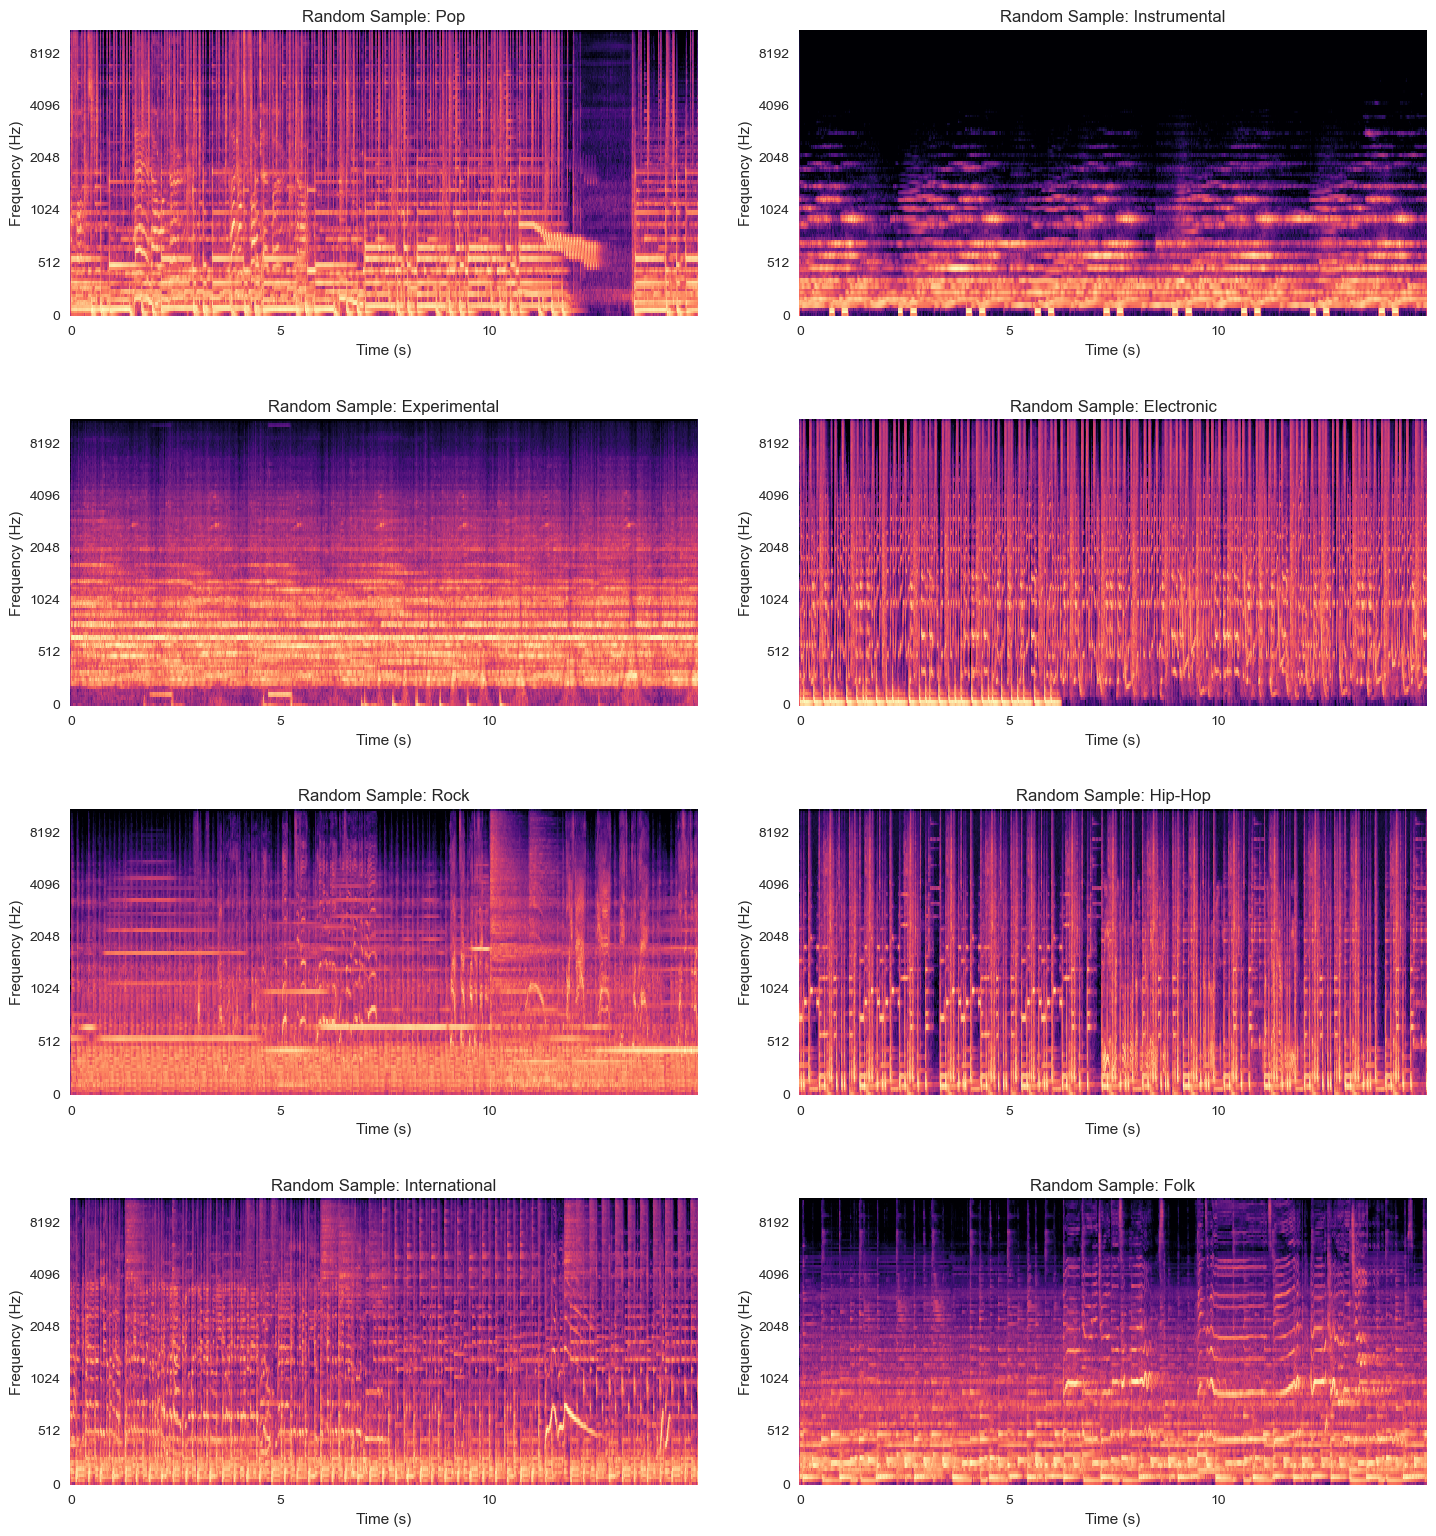

In [26]:
def plot_random_genre_spectrograms(df, sr=TARGET_SR):
    """
    Selects one random sample per genre and plots them in a 4x2 grid.
    """
    genres = df['genre'].unique()
    
    # Setup the figure grid: 4 rows x 2 columns
    fig, axs = plt.subplots(4, 2, figsize=(15, 16))
    axs = axs.flatten()
    
    for i, genre in enumerate(genres):
        # Select a random song path for the current genre
        random_song_path = df[df['genre'] == genre].sample(1, random_state=42)['path'].iloc[0]
        
        try:
            # Load audio (using consistent parameters)
            y, _ = librosa.load(random_song_path, sr=sr, duration=DURATION)
            
            # Calculate Mel-Spectrogram
            mel_spect = librosa.feature.melspectrogram(
                y=y, sr=sr, n_fft=2048, hop_length=1024
            )
            mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)
            
            # Plotting with improved contrast
            img = librosa.display.specshow(
                mel_spect_db, ax=axs[i], sr=sr, 
                x_axis='time', y_axis='mel', 
                cmap='magma' # 'magma' provides better spectral contrast
            )
            axs[i].set_title(f'Random Sample: {genre}')
            axs[i].set_xlabel('Time (s)')
            axs[i].set_ylabel('Frequency (Hz)')
            
        except Exception as e:
            axs[i].set_title(f'Error loading {genre}: {e}', fontsize=9)
            
    # Remove empty subplots if the number of genres < 8
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
        
    plt.tight_layout(pad=3.0)
    plt.savefig(os.path.join('./images', 'genre_spectrograms.png'), dpi=500)
    plt.show()

# Execute the visualization
plot_random_genre_spectrograms(train_df)

### **Scaling**

In [12]:
# Initialize the tools
scaler = StandardScaler()
le = LabelEncoder()

# Fit and transform the labels (targets)
y_train = le.fit_transform(train_df['genre'])
y_val = le.transform(val_df['genre'])
y_test = le.transform(test_df['genre'])

# Fit the scaler ONLY on the training features (crucial to prevent data leakage)
# Then apply the transformation to all sets
X_train_ml_scaled = scaler.fit_transform(X_train_ml)
X_val_ml_scaled = scaler.transform(X_val_ml)
X_test_ml_scaled = scaler.transform(X_test_ml)

print("Scaling and Label Encoding complete.")

Scaling and Label Encoding complete.


## **6+7. Set up and configure the modeling algorithm (e.g., classifier or regressor), train the model using the training set, evaluate model performance using the test set**

### **Random Forest**

In [13]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_ml_scaled, y_train)
rf_preds = rf_model.predict(X_test_ml_scaled)

print(f'RandomForest - Train score: {np.round(rf_model.score(X_train_ml_scaled, y_train), 4)}')
print(f'RandomForest - Test score: {np.round(rf_model.score(X_test_ml_scaled, y_test), 4)}')

print("\n Random Forest Classification Report:\n")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

RandomForest - Train score: 0.9998
RandomForest - Test score: 0.5112

 Random Forest Classification Report:

               precision    recall  f1-score   support

   Electronic       0.48      0.50      0.49       100
 Experimental       0.43      0.32      0.37       100
         Folk       0.55      0.66      0.60       100
      Hip-Hop       0.57      0.67      0.61       100
 Instrumental       0.61      0.61      0.61       100
International       0.56      0.44      0.49       100
          Pop       0.33      0.27      0.30       100
         Rock       0.50      0.62      0.55       100

     accuracy                           0.51       800
    macro avg       0.50      0.51      0.50       800
 weighted avg       0.50      0.51      0.50       800



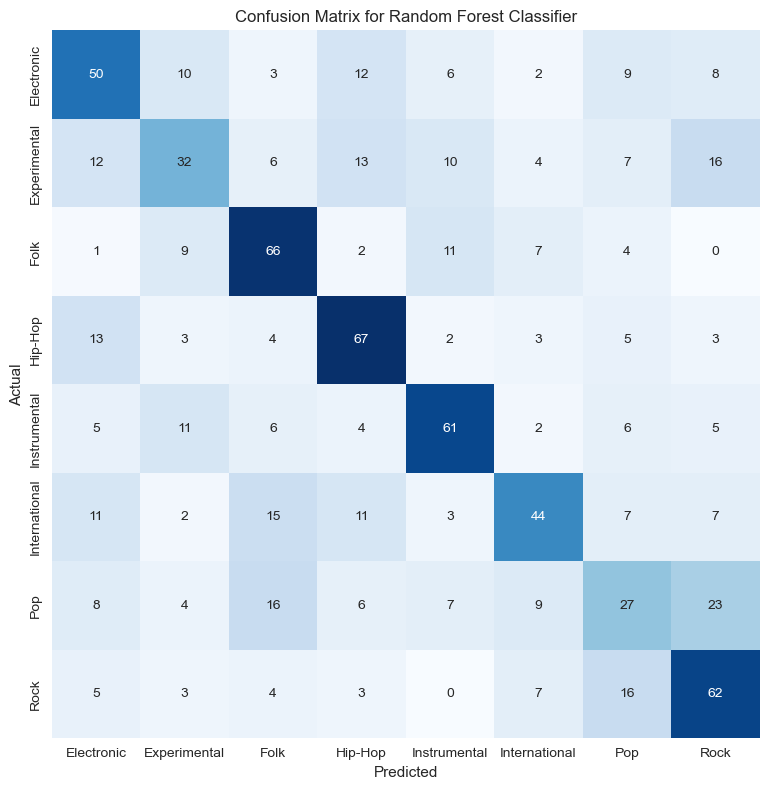

In [14]:
rf_cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', 
            cbar=False,
            square=True,
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join('./images', 'rf_cm.png'), dpi=500)
plt.show()

### **SVM**

In [15]:
# SVM with RBF kernel
model_svm = SVC(kernel='rbf', C=0.8, gamma='scale')
model_svm.fit(X_train_ml_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_ml_scaled)

print(f'SVM (with rbf) - Train score: {np.round(model_svm.score(X_train_ml_scaled, y_train), 4)}')
print(f'SVM (with rbf) - Test score: {np.round(model_svm.score(X_test_ml_scaled, y_test), 4)}')

print("\n SVM Classification Report::\n")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM (with rbf) - Train score: 0.6287
SVM (with rbf) - Test score: 0.5175

 SVM Classification Report::

               precision    recall  f1-score   support

   Electronic       0.45      0.54      0.49       100
 Experimental       0.35      0.25      0.29       100
         Folk       0.58      0.69      0.63       100
      Hip-Hop       0.61      0.69      0.65       100
 Instrumental       0.60      0.52      0.56       100
International       0.65      0.57      0.61       100
          Pop       0.34      0.28      0.31       100
         Rock       0.50      0.60      0.55       100

     accuracy                           0.52       800
    macro avg       0.51      0.52      0.51       800
 weighted avg       0.51      0.52      0.51       800



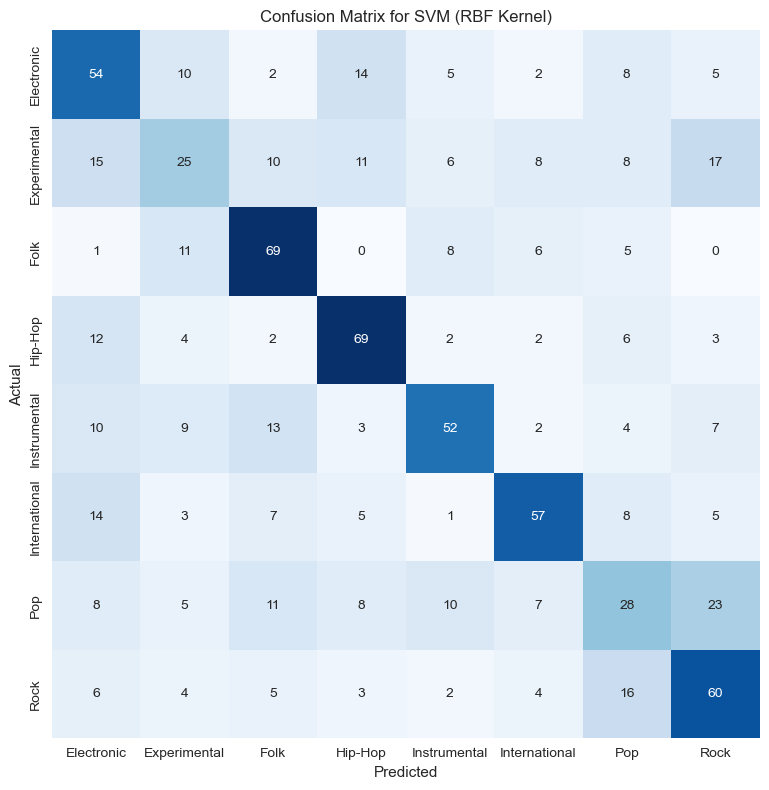

In [16]:
svm_cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', 
            cbar=False,
            square=True,
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix for SVM (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join('./images', 'svm_cm.png'), dpi=500)
plt.show()

### **MLP**

In [17]:
mlp_params = {
    'hidden_layer_sizes': (512, 256, 128),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.01,           # L2 regularization (fundamental to prevent overfitting)
    'batch_size': 32,
    'learning_rate_init': 0.001,
    'max_iter': 500,
    'early_stopping': True
}

mlp_model = MLPClassifier(**mlp_params, random_state=42)
    
mlp_model.fit(X_train_ml_scaled, y_train)
    
predictions = mlp_model.predict(X_val_ml_scaled)
accuracy = accuracy_score(y_val, predictions)

In [18]:
train_score_mlp = mlp_model.score(X_train_ml_scaled, y_train)

print(f"MLP - Train score: {np.round(train_score_mlp, 4)}")
print(f"MLP - Test score: {np.round(accuracy, 4)}")

print("\nClassification Report:")
print(classification_report(y_val, predictions, target_names=le.classes_))

MLP - Train score: 0.824
MLP - Test score: 0.4875

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.56      0.51      0.53       100
 Experimental       0.36      0.42      0.39       100
         Folk       0.52      0.53      0.52       100
      Hip-Hop       0.64      0.66      0.65       100
 Instrumental       0.47      0.46      0.46       100
International       0.47      0.46      0.47       100
          Pop       0.32      0.29      0.31       100
         Rock       0.55      0.57      0.56       100

     accuracy                           0.49       800
    macro avg       0.49      0.49      0.49       800
 weighted avg       0.49      0.49      0.49       800



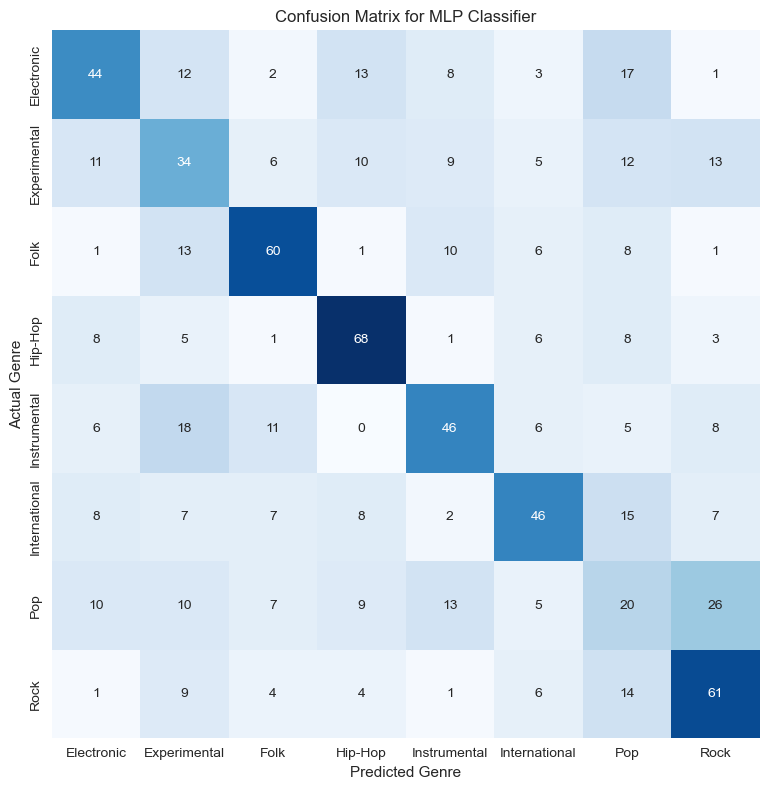

In [19]:
y_pred_mlp = mlp_model.predict(X_test_ml_scaled)
mlp_cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', 
            cbar=False,
            square=True,
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix for MLP Classifier')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.savefig(os.path.join('./images', 'mlp_cm.png'), dpi=500)
plt.show()

### **CNN**

In [20]:
# Adding channel dimension for CNN input (from 3D to 4D) and downsampling the time dimension by a factor of 4
X_train_cnn_ready = X_train_cnn[:, :, ::4, np.newaxis]
X_val_cnn_ready = X_val_cnn[:, :, ::4, np.newaxis]
X_test_cnn_ready = X_test_cnn[:, :, ::4, np.newaxis]

# Compute mean and std from training set for normalization
train_mean = np.mean(X_train_cnn_ready)
train_std = np.std(X_train_cnn_ready)

# Z-score normalization using training set statistics
X_train_cnn_scaled = (X_train_cnn_ready - train_mean) / (train_std + 1e-7)
X_val_cnn_scaled = (X_val_cnn_ready - train_mean) / (train_std + 1e-7)
X_test_cnn_scaled = (X_test_cnn_ready - train_mean) / (train_std + 1e-7)

print("New shape 4D:", X_train_cnn_scaled.shape)

New shape 4D: (6397, 128, 323, 1)


In [21]:
model_cnn = Sequential([
    # Input shape explicitly defined
    Input(shape=(128, 1292, 1)),

    # 1: base feature extraction
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Result: 64 x 646

    # 2: intermediate features
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Result: 32 x 323

    # 3: complex features
    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)), # Result: 16 x 161

    # Final reduction
    GlobalAveragePooling2D(),
    
    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(np.unique(y_train)), activation='softmax')
])

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 1292, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1292, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 646, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 646, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 646, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 323, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 323, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 323, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,
    patience=3, 
    min_lr=0.00001
)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
# model_cnn.compile(optimizer=Adam(learning_rate=0.001),
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])

# history = model_cnn.fit(
#     X_train_cnn_scaled, y_train,
#     validation_data=(X_val_cnn_scaled, y_val),
#     epochs=50,
#     batch_size=64,
#     class_weight=class_weights_dict, 
#     callbacks=[early_stop, lr_scheduler]
# )

```
WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 280s 3s/step - accuracy: 0.3486 - loss: 1.7618 - val_accuracy: 0.1250 - val_loss: 2.8018 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.4327 - loss: 1.5839 - val_accuracy: 0.1250 - val_loss: 4.2028 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.4771 - loss: 1.4819 - val_accuracy: 0.1250 - val_loss: 3.7063 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5107 - loss: 1.4072 - val_accuracy: 0.1475 - val_loss: 2.5306 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.5259 - loss: 1.3555 - val_accuracy: 0.3200 - val_loss: 2.0676 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.5407 - loss: 1.3237 - val_accuracy: 0.4825 - val_loss: 1.4826 - learning_rate: 0.0010
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.5418 - loss: 1.3088 - val_accuracy: 0.4900 - val_loss: 1.4608 - learning_rate: 0.0010
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.5632 - loss: 1.2566 - val_accuracy: 0.5063 - val_loss: 1.4082 - learning_rate: 0.0010
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5715 - loss: 1.2435 - val_accuracy: 0.4913 - val_loss: 1.3996 - learning_rate: 0.0010
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.5861 - loss: 1.2000 - val_accuracy: 0.5437 - val_loss: 1.3141 - learning_rate: 0.0010
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5901 - loss: 1.1800 - val_accuracy: 0.5138 - val_loss: 1.4807 - learning_rate: 0.0010
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.6033 - loss: 1.1615 - val_accuracy: 0.5288 - val_loss: 1.3426 - learning_rate: 0.0010
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.6134 - loss: 1.1388 - val_accuracy: 0.5150 - val_loss: 1.4082 - learning_rate: 0.0010
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.6383 - loss: 1.0568 - val_accuracy: 0.5950 - val_loss: 1.2022 - learning_rate: 2.0000e-04
Epoch 15/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.6491 - loss: 1.0261 - val_accuracy: 0.6125 - val_loss: 1.1751 - learning_rate: 2.0000e-04
Epoch 16/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.6594 - loss: 1.0068 - val_accuracy: 0.5962 - val_loss: 1.2056 - learning_rate: 2.0000e-04
Epoch 17/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.6636 - loss: 1.0036 - val_accuracy: 0.6025 - val_loss: 1.1719 - learning_rate: 2.0000e-04
Epoch 18/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.6658 - loss: 0.9922 - val_accuracy: 0.5750 - val_loss: 1.2408 - learning_rate: 2.0000e-04
Epoch 19/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.6677 - loss: 0.9849 - val_accuracy: 0.6137 - val_loss: 1.1556 - learning_rate: 2.0000e-04
Epoch 20/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.6673 - loss: 0.9763 - val_accuracy: 0.5987 - val_loss: 1.1737 - learning_rate: 2.0000e-04
Epoch 21/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.6742 - loss: 0.9641 - val_accuracy: 0.5700 - val_loss: 1.2370 - learning_rate: 2.0000e-04
Epoch 22/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.6784 - loss: 0.9531 - val_accuracy: 0.6050 - val_loss: 1.1862 - learning_rate: 2.0000e-04
Epoch 23/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.6874 - loss: 0.9244 - val_accuracy: 0.6175 - val_loss: 1.1365 - learning_rate: 4.0000e-05
Epoch 24/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.6878 - loss: 0.9147 - val_accuracy: 0.6237 - val_loss: 1.1414 - learning_rate: 4.0000e-05
Epoch 25/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.6928 - loss: 0.9146 - val_accuracy: 0.6137 - val_loss: 1.1383 - learning_rate: 4.0000e-05
Epoch 26/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.6924 - loss: 0.9118 - val_accuracy: 0.6200 - val_loss: 1.1373 - learning_rate: 4.0000e-05
Epoch 27/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.6944 - loss: 0.8993 - val_accuracy: 0.6137 - val_loss: 1.1330 - learning_rate: 1.0000e-05
Epoch 28/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.6902 - loss: 0.9093 - val_accuracy: 0.6187 - val_loss: 1.1341 - learning_rate: 1.0000e-05
Epoch 29/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.6960 - loss: 0.9017 - val_accuracy: 0.6187 - val_loss: 1.1360 - learning_rate: 1.0000e-05
Epoch 30/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.6927 - loss: 0.9013 - val_accuracy: 0.6187 - val_loss: 1.1354 - learning_rate: 1.0000e-05
Epoch 31/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.6964 - loss: 0.9061 - val_accuracy: 0.6175 - val_loss: 1.1351 - learning_rate: 1.0000e-05
Epoch 32/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.6930 - loss: 0.9032 - val_accuracy: 0.6187 - val_loss: 1.1385 - learning_rate: 1.0000e-05
```

In [24]:
# output_folder = 'cnn_test_1'

# os.makedirs(output_folder, exist_ok=True)

# model_cnn.save(os.path.join(output_folder, 'cnn.keras'))
# print("Model saved.")

# np.save(os.path.join(output_folder, 'X_test_cnn_scaled.npy'), X_test_cnn_scaled)
# np.save(os.path.join(output_folder, 'y_test_cnn.npy'), y_test)

# with open(os.path.join(output_folder, 'history.pkl'), 'wb') as f:
#     pickle.dump(history.history, f)
# print("History saved.")

# joblib.dump(scaler, os.path.join(output_folder, 'scaler.pkl'))
# joblib.dump(le, os.path.join(output_folder, 'label_encoder.pkl'))

# params = {
#     "sample_rate": 22050, 
#     "duration": 30,
#     "n_mels": 128,
#     "hop_length": 512
# }
# with open(os.path.join(output_folder, 'params.json'), 'w') as f:
#     json.dump(params, f, indent=4)

# with open(os.path.join(output_folder, 'model_summary.txt'), 'w') as f:
#     model_cnn.summary(print_fn=lambda x: f.write(x + '\n'))

# print("Parameters and architecture summary saved.")

# print(f"Everything correctly saved in: {output_folder}")

Model loaded successfully.
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step


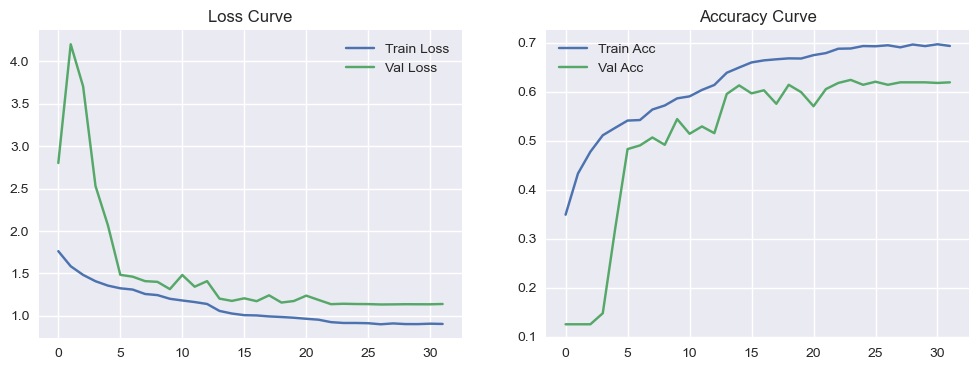

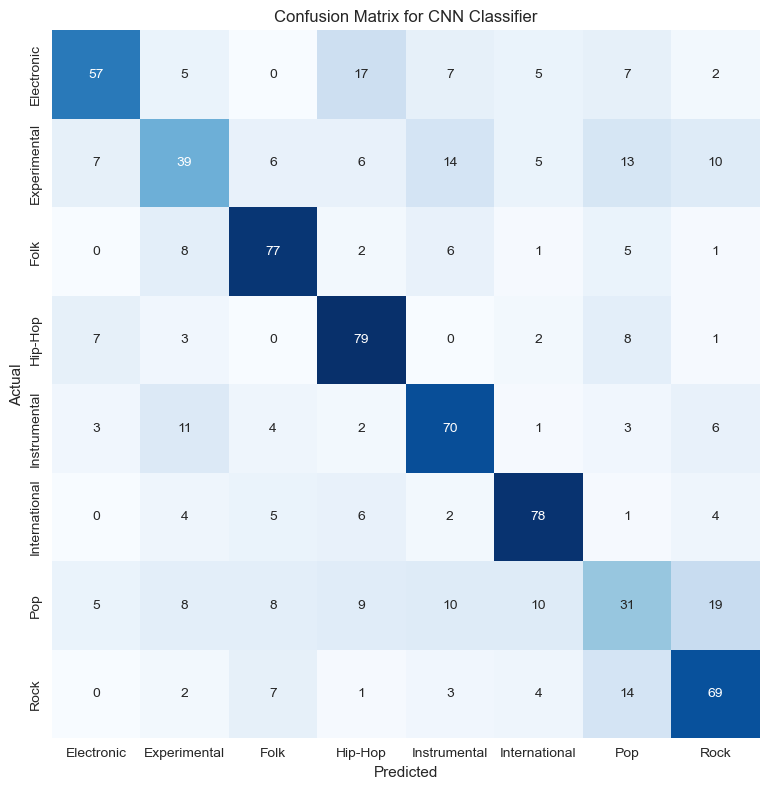

               precision    recall  f1-score   support

   Electronic       0.72      0.57      0.64       100
 Experimental       0.49      0.39      0.43       100
         Folk       0.72      0.77      0.74       100
      Hip-Hop       0.65      0.79      0.71       100
 Instrumental       0.62      0.70      0.66       100
International       0.74      0.78      0.76       100
          Pop       0.38      0.31      0.34       100
         Rock       0.62      0.69      0.65       100

     accuracy                           0.62       800
    macro avg       0.62      0.62      0.62       800
 weighted avg       0.62      0.62      0.62       800



In [25]:
# Load the trained CNN model
model_path = os.path.join('cnn_test_1', 'cnn.keras')
model_cnn = load_model(model_path)
print("Model loaded successfully.")

# Load the results
output_folder = 'cnn_test_1'
with open(os.path.join(output_folder, 'history.pkl'), 'rb') as f:
    history_test_1 = pickle.load(f)

# Test set predictions
y_pred = model_cnn.predict(X_test_cnn_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# Plot Training Curves (Loss and Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_test_1['loss'], label='Train Loss')
plt.plot(history_test_1['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history_test_1['accuracy'], label='Train Acc')
plt.plot(history_test_1['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curve')
plt.savefig(os.path.join('./images', 'cnn_training_curves.png'), dpi=500)
plt.show()

# Confusion Matrix
cnn_cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', 
            cbar=False,  # Barra rimossa per coerenza
            square=True,
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.title('Confusion Matrix for CNN Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join('./images', 'cnn_cm.png'), dpi=500)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))